<a href="https://colab.research.google.com/github/spatel418/nw_msai_437_event_recommendation/blob/main/yelp_illinois_collaborative_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yelp Illinois Collaborative Filtering Analysis

**Project Goal**: Build a collaborative filtering recommendation system focused on Illinois businesses

**Key Benefits of Illinois Focus**:
- Dramatically reduced RAM usage (~90% reduction)
- Faster processing and iteration
- More dense user-item matrix (better recommendations)
- Focus on Chicago metro area (major market)

**Author**: Simron  
**Environment**: Google Colab (Free or Pro)

In [1]:
# Install required packages
!pip install scikit-learn matplotlib seaborn numpy pandas scipy psutil --quiet

# Import libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, TruncatedSVD
from scipy.sparse import csr_matrix
import warnings
import gc
import psutil
import os
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('default')

# Memory monitoring function
def print_memory_usage(stage=""):
    """Print current memory usage"""
    process = psutil.Process()
    memory_mb = process.memory_info().rss / 1024 / 1024
    print(f"🔍 Memory Usage {stage}: {memory_mb:.1f} MB")
    gc.collect()
    return memory_mb

print("✅ All packages imported successfully!")
print_memory_usage("after imports")

✅ All packages imported successfully!
🔍 Memory Usage after imports: 244.7 MB


244.6640625

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set your dataset path
DATASET_PATH = '/content/drive/MyDrive/Yelp-JSON/Yelp JSON/yelp_dataset'

# Verify files exist
required_files = [
    'yelp_academic_dataset_business.json',
    'yelp_academic_dataset_user.json',
    'yelp_academic_dataset_review.json'
]

print("Checking for required files...")
for file in required_files:
    file_path = os.path.join(DATASET_PATH, file)
    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024*1024)
        print(f"✅ {file} ({size_mb:.1f} MB)")
    else:
        print(f"❌ {file} - NOT FOUND")
        print(f"   Expected at: {file_path}")

Mounted at /content/drive
Checking for required files...
✅ yelp_academic_dataset_business.json (113.4 MB)
✅ yelp_academic_dataset_user.json (3207.5 MB)
✅ yelp_academic_dataset_review.json (5094.4 MB)


## Step 1: Load Illinois Businesses Only

First, we'll identify all businesses in Illinois (IL) to dramatically reduce our dataset size.

In [3]:
# Load Illinois businesses only
print("Loading Illinois businesses...")
print_memory_usage("before loading businesses")

illinois_businesses = []
total_businesses = 0

with open(f"{DATASET_PATH}/yelp_academic_dataset_business.json", 'r') as f:
    for line in tqdm(f, desc="Filtering Illinois businesses"):
        business = json.loads(line)
        total_businesses += 1

        # Only keep Illinois businesses
        if business.get('state') == 'IL':
            illinois_businesses.append(business)

businesses_df = pd.DataFrame(illinois_businesses)

print(f"\n📊 Business Statistics:")
print(f"Total businesses in dataset: {total_businesses:,}")
print(f"Illinois businesses: {len(businesses_df):,}")
print(f"Data reduction: {(1 - len(businesses_df)/total_businesses)*100:.1f}%")

print_memory_usage("after loading Illinois businesses")

# Show top cities in Illinois
if len(businesses_df) > 0:
    print(f"\n🏙️ Top Illinois Cities:")
    city_counts = businesses_df['city'].value_counts().head(10)
    for city, count in city_counts.items():
        print(f"  {city}: {count:,} businesses")
else:
    print("❌ No Illinois businesses found! Check your dataset.")

# Clean up memory
del illinois_businesses
gc.collect()

Loading Illinois businesses...
🔍 Memory Usage before loading businesses: 244.7 MB


Filtering Illinois businesses: 150346it [00:08, 16759.79it/s]



📊 Business Statistics:
Total businesses in dataset: 150,346
Illinois businesses: 2,145
Data reduction: 98.6%
🔍 Memory Usage after loading Illinois businesses: 253.2 MB

🏙️ Top Illinois Cities:
  Belleville: 302 businesses
  Edwardsville: 274 businesses
  Fairview Heights: 241 businesses
  Collinsville: 159 businesses
  O'Fallon: 153 businesses
  Alton: 150 businesses
  O Fallon: 85 businesses
  Granite City: 75 businesses
  Glen Carbon: 73 businesses
  Swansea: 58 businesses


0

In [4]:
# Load reviews for Illinois businesses only
print("Loading reviews for Illinois businesses...")
print_memory_usage("before loading reviews")

# Get Illinois business IDs for filtering
illinois_business_ids = set(businesses_df['business_id'])
print(f"Filtering for {len(illinois_business_ids):,} Illinois businesses")

illinois_reviews = []
total_reviews_processed = 0
chunk_size = 100000  # Process in 100k chunks

with open(f"{DATASET_PATH}/yelp_academic_dataset_review.json", 'r') as f:
    for line in tqdm(f, desc="Loading Illinois reviews"):
        total_reviews_processed += 1
        review = json.loads(line)

        # Only keep reviews for Illinois businesses
        if review['business_id'] in illinois_business_ids:
            illinois_reviews.append(review)

        # Memory management: process in chunks
        if total_reviews_processed % chunk_size == 0:
            current_memory = print_memory_usage(f"after {total_reviews_processed:,} reviews")
            print(f"   Found {len(illinois_reviews):,} Illinois reviews so far")

            # If memory gets too high, break (optional safety)
            if current_memory > 8000:  # 8GB threshold
                print("⚠️  High memory usage detected, stopping early")
                break

reviews_df = pd.DataFrame(illinois_reviews)

print(f"\n📊 Review Statistics:")
print(f"Total reviews processed: {total_reviews_processed:,}")
print(f"Illinois reviews found: {len(reviews_df):,}")
if total_reviews_processed > 0:
    print(f"Illinois review rate: {len(reviews_df)/total_reviews_processed*100:.2f}%")

print_memory_usage("after loading Illinois reviews")

# Clean up
del illinois_reviews
gc.collect()

Loading reviews for Illinois businesses...
🔍 Memory Usage before loading reviews: 253.8 MB
Filtering for 2,145 Illinois businesses


Loading Illinois reviews: 99566it [00:04, 30966.01it/s]

🔍 Memory Usage after 100,000 reviews: 253.9 MB


Loading Illinois reviews: 106316it [00:04, 22243.24it/s]

   Found 675 Illinois reviews so far


...

Loading Illinois reviews: 6903576it [01:53, 59864.51it/s]

🔍 Memory Usage after 6,900,000 reviews: 330.5 MB
   Found 51,218 Illinois reviews so far


Loading Illinois reviews: 6990280it [01:54, 61090.35it/s]



📊 Review Statistics:
Total reviews processed: 6,990,280
Illinois reviews found: 51,832
Illinois review rate: 0.74%
🔍 Memory Usage after loading Illinois reviews: 344.1 MB


0

In [5]:
# Load users who reviewed Illinois businesses
print("Loading relevant users...")
print_memory_usage("before loading users")

# Get user IDs who reviewed Illinois businesses
illinois_user_ids = set(reviews_df['user_id'])
print(f"Looking for {len(illinois_user_ids):,} users who reviewed Illinois businesses")

illinois_users = []
total_users_processed = 0

with open(f"{DATASET_PATH}/yelp_academic_dataset_user.json", 'r') as f:
    for line in tqdm(f, desc="Loading relevant users"):
        total_users_processed += 1
        user = json.loads(line)

        # Only keep users who reviewed Illinois businesses
        if user['user_id'] in illinois_user_ids:
            illinois_users.append(user)

        # Memory check every 500k users
        if total_users_processed % 500000 == 0:
            print_memory_usage(f"after {total_users_processed:,} users")
            print(f"   Found {len(illinois_users):,} relevant users so far")

users_df = pd.DataFrame(illinois_users)

print(f"\n📊 User Statistics:")
print(f"Total users processed: {total_users_processed:,}")
print(f"Relevant users found: {len(users_df):,}")

print_memory_usage("after loading users")

# Final dataset statistics
print(f"\n🎯 Final Illinois Dataset:")
print(f"  Reviews: {len(reviews_df):,}")
print(f"  Businesses: {len(businesses_df):,}")
print(f"  Users: {len(users_df):,}")

# Calculate matrix density
total_possible = len(users_df) * len(businesses_df)
density = len(reviews_df) / total_possible if total_possible > 0 else 0
print(f"  Matrix density: {density:.6f} ({density*100:.4f}%)")
print(f"  Sparsity: {1-density:.6f} ({(1-density)*100:.4f}%)")

# Clean up
del illinois_users
gc.collect()

Loading relevant users...
🔍 Memory Usage before loading users: 344.1 MB
Looking for 22,248 users who reviewed Illinois businesses


Loading relevant users: 505873it [00:22, 24815.39it/s]

🔍 Memory Usage after 500,000 users: 355.7 MB
   Found 8,000 relevant users so far


Loading relevant users: 1003877it [00:34, 45977.20it/s]

🔍 Memory Usage after 1,000,000 users: 364.2 MB
   Found 13,464 relevant users so far


Loading relevant users: 1509394it [00:49, 62744.78it/s]

🔍 Memory Usage after 1,500,000 users: 372.0 MB
   Found 18,032 relevant users so far


Loading relevant users: 1987897it [01:02, 31935.38it/s] 



📊 User Statistics:
Total users processed: 1,987,897
Relevant users found: 22,247
🔍 Memory Usage after loading users: 395.5 MB

🎯 Final Illinois Dataset:
  Reviews: 51,832
  Businesses: 2,145
  Users: 22,247
  Matrix density: 0.001086 (0.1086%)
  Sparsity: 0.998914 (99.8914%)


0

## Step 2: Illinois-Specific Analysis

In [6]:
# Analyze Illinois dataset
print("Analyzing Illinois Yelp data...")

# Rating distribution
print("\n⭐ Rating Distribution:")
rating_dist = reviews_df['stars'].value_counts().sort_index()
for rating, count in rating_dist.items():
    print(f"{rating} stars: {count:,} ({count/len(reviews_df)*100:.1f}%)")

# Geographic distribution within Illinois
print("\n🏙️ Top 15 Illinois Cities by Review Count:")
city_reviews = reviews_df.merge(businesses_df[['business_id', 'city']], on='business_id')
city_review_counts = city_reviews['city'].value_counts().head(15)
for city, count in city_review_counts.items():
    print(f"{city}: {count:,} reviews")

# Business categories (if available)
if 'categories' in businesses_df.columns:
    print("\n🍕 Popular Business Categories:")
    all_categories = []
    for categories in businesses_df['categories'].dropna():
        if isinstance(categories, str):
            all_categories.extend([cat.strip() for cat in categories.split(',')])

    from collections import Counter
    top_categories = Counter(all_categories).most_common(10)
    for category, count in top_categories:
        print(f"{category}: {count:,} businesses")

# User activity in Illinois
user_activity = reviews_df['user_id'].value_counts()
print(f"\n👥 User Activity Statistics:")
print(f"Average reviews per user: {user_activity.mean():.2f}")
print(f"Median reviews per user: {user_activity.median():.2f}")
print(f"Most active user: {user_activity.max():,} reviews")
print(f"Users with 1 review: {(user_activity == 1).sum():,} ({(user_activity == 1).sum()/len(user_activity)*100:.1f}%)")
print(f"Users with 5+ reviews: {(user_activity >= 5).sum():,} ({(user_activity >= 5).sum()/len(user_activity)*100:.1f}%)")

# Business popularity
business_popularity = reviews_df['business_id'].value_counts()
print(f"\n🏢 Business Popularity:")
print(f"Average reviews per business: {business_popularity.mean():.2f}")
print(f"Median reviews per business: {business_popularity.median():.2f}")
print(f"Most reviewed business: {business_popularity.max():,} reviews")

print_memory_usage("after analysis")

Analyzing Illinois Yelp data...

⭐ Rating Distribution:
1.0 stars: 10,556 (20.4%)
2.0 stars: 4,819 (9.3%)
3.0 stars: 5,307 (10.2%)
4.0 stars: 9,828 (19.0%)
5.0 stars: 21,322 (41.1%)

🏙️ Top 15 Illinois Cities by Review Count:
Edwardsville: 8,526 reviews
Belleville: 7,562 reviews
Fairview Heights: 6,593 reviews
O'Fallon: 5,541 reviews
Collinsville: 3,775 reviews
Alton: 3,605 reviews
O Fallon: 1,636 reviews
Shiloh: 1,517 reviews
Glen Carbon: 1,225 reviews
Granite City: 1,109 reviews
Swansea: 1,063 reviews
Columbia: 1,062 reviews
Troy: 987 reviews
Waterloo: 979 reviews
Maryville: 726 reviews

🍕 Popular Business Categories:
Restaurants: 983 businesses
Food: 405 businesses
Shopping: 321 businesses
American (Traditional): 234 businesses
Fast Food: 224 businesses
Nightlife: 204 businesses
Bars: 186 businesses
Burgers: 184 businesses
Automotive: 169 businesses
Event Planning & Services: 161 businesses

👥 User Activity Statistics:
Average reviews per user: 2.33
Median reviews per user: 1.00
Mos

396.45703125

Creating visualizations...


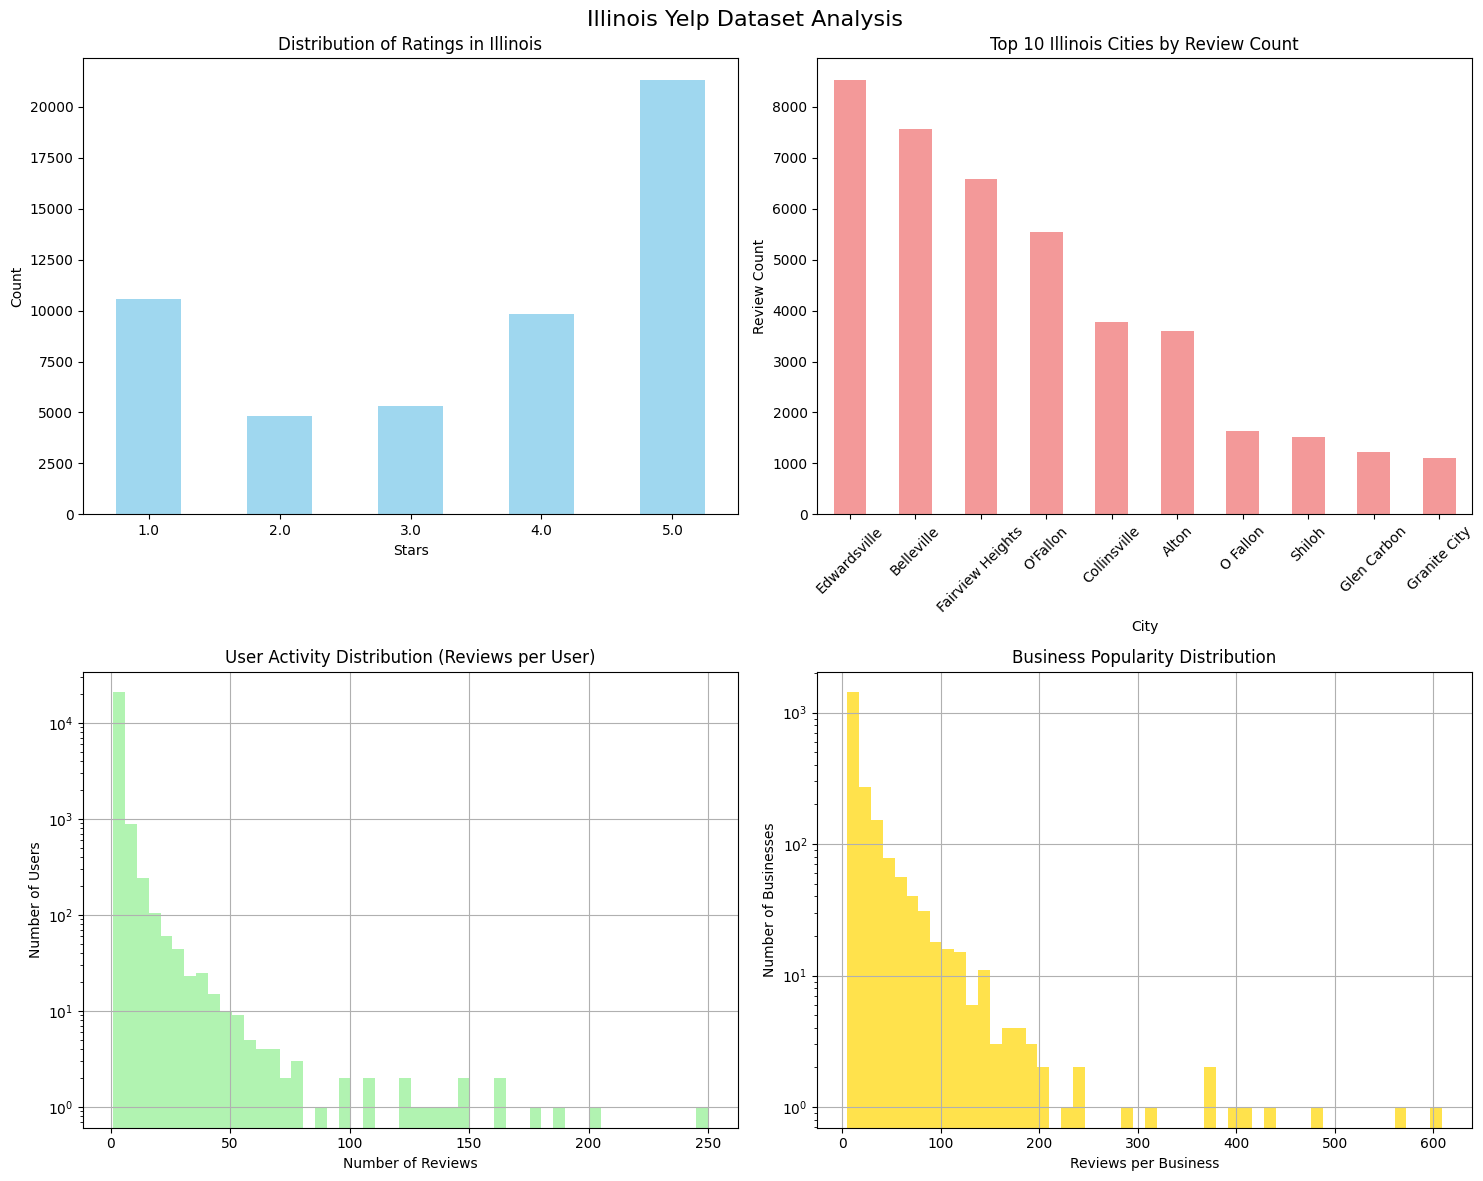

🔍 Memory Usage after visualizations: 406.7 MB


406.71484375

In [7]:
# Create visualizations
print("Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Illinois Yelp Dataset Analysis', fontsize=16)

# Rating distribution
rating_dist.plot(kind='bar', ax=axes[0,0], color='skyblue', alpha=0.8)
axes[0,0].set_title('Distribution of Ratings in Illinois')
axes[0,0].set_xlabel('Stars')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Top cities
city_review_counts.head(10).plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
axes[0,1].set_title('Top 10 Illinois Cities by Review Count')
axes[0,1].set_xlabel('City')
axes[0,1].set_ylabel('Review Count')
axes[0,1].tick_params(axis='x', rotation=45)

# User activity distribution (log scale)
user_activity.hist(bins=50, ax=axes[1,0], color='lightgreen', alpha=0.7)
axes[1,0].set_title('User Activity Distribution (Reviews per User)')
axes[1,0].set_xlabel('Number of Reviews')
axes[1,0].set_ylabel('Number of Users')
axes[1,0].set_yscale('log')

# Business popularity distribution (log scale)
business_popularity.hist(bins=50, ax=axes[1,1], color='gold', alpha=0.7)
axes[1,1].set_title('Business Popularity Distribution')
axes[1,1].set_xlabel('Reviews per Business')
axes[1,1].set_ylabel('Number of Businesses')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

print_memory_usage("after visualizations")

## Step 3: Optional Activity Filtering

To further improve recommendation quality, we can filter out users/businesses with very few reviews.

In [8]:
# Optional: Filter by minimum activity levels
print("Applying activity filtering...")

# Set minimum thresholds
MIN_USER_REVIEWS = 3    # Users must have at least 3 reviews
MIN_BUSINESS_REVIEWS = 5  # Businesses must have at least 5 reviews

print(f"Filtering criteria:")
print(f"  Minimum user reviews: {MIN_USER_REVIEWS}")
print(f"  Minimum business reviews: {MIN_BUSINESS_REVIEWS}")

# Get active users and popular businesses
user_counts = reviews_df['user_id'].value_counts()
business_counts = reviews_df['business_id'].value_counts()

active_users = user_counts[user_counts >= MIN_USER_REVIEWS].index
popular_businesses = business_counts[business_counts >= MIN_BUSINESS_REVIEWS].index

print(f"\nBefore filtering:")
print(f"  Users: {len(users_df):,}")
print(f"  Businesses: {len(businesses_df):,}")
print(f"  Reviews: {len(reviews_df):,}")

# Filter datasets
reviews_df_filtered = reviews_df[
    (reviews_df['user_id'].isin(active_users)) &
    (reviews_df['business_id'].isin(popular_businesses))
].copy()

# Update user and business dataframes
remaining_user_ids = set(reviews_df_filtered['user_id'])
remaining_business_ids = set(reviews_df_filtered['business_id'])

users_df_filtered = users_df[users_df['user_id'].isin(remaining_user_ids)].copy()
businesses_df_filtered = businesses_df[businesses_df['business_id'].isin(remaining_business_ids)].copy()

print(f"\nAfter filtering:")
print(f"  Users: {len(users_df_filtered):,} (-{len(users_df)-len(users_df_filtered):,})")
print(f"  Businesses: {len(businesses_df_filtered):,} (-{len(businesses_df)-len(businesses_df_filtered):,})")
print(f"  Reviews: {len(reviews_df_filtered):,} (-{len(reviews_df)-len(reviews_df_filtered):,})")

# Calculate new density
new_total_possible = len(users_df_filtered) * len(businesses_df_filtered)
new_density = len(reviews_df_filtered) / new_total_possible if new_total_possible > 0 else 0
print(f"  New matrix density: {new_density:.6f} ({new_density*100:.4f}%)")
print(f"  Density improvement: {new_density/density:.2f}x" if density > 0 else "")

# Decide whether to use filtered data
USE_FILTERED = True  # Set to False if you want to keep all data

if USE_FILTERED:
    reviews_df = reviews_df_filtered
    users_df = users_df_filtered
    businesses_df = businesses_df_filtered
    print("\n✅ Using filtered dataset for better recommendation quality")
else:
    print("\n📊 Using full Illinois dataset (no activity filtering)")

print_memory_usage("after activity filtering")

# Clean up
del reviews_df_filtered, users_df_filtered, businesses_df_filtered
gc.collect()

Applying activity filtering...
Filtering criteria:
  Minimum user reviews: 3
  Minimum business reviews: 5

Before filtering:
  Users: 22,247
  Businesses: 2,145
  Reviews: 51,832

After filtering:
  Users: 3,953 (-18,294)
  Businesses: 2,106 (-39)
  Reviews: 30,467 (-21,365)
  New matrix density: 0.003660 (0.3660%)
  Density improvement: 3.37x

✅ Using filtered dataset for better recommendation quality
🔍 Memory Usage after activity filtering: 407.3 MB


0

## Step 4: Create User-Item Matrix

Now we'll create the sparse matrix for collaborative filtering.

In [9]:
print("Creating user-item matrix for Illinois data...")
print_memory_usage("before matrix creation")

# Create mappings
unique_users = reviews_df['user_id'].unique()
unique_businesses = reviews_df['business_id'].unique()

print(f"Matrix dimensions: {len(unique_users):,} users × {len(unique_businesses):,} businesses")

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}
business_to_idx = {business: idx for idx, business in enumerate(unique_businesses)}
idx_to_business = {idx: business for business, idx in business_to_idx.items()}

# Build sparse matrix
print("Building sparse matrix...")
row_indices = []
col_indices = []
ratings = []

for _, review in tqdm(reviews_df.iterrows(), total=len(reviews_df), desc="Processing reviews"):
    user_idx = user_to_idx[review['user_id']]
    business_idx = business_to_idx[review['business_id']]

    row_indices.append(user_idx)
    col_indices.append(business_idx)
    ratings.append(review['stars'])

# Create sparse matrix
user_item_matrix = csr_matrix(
    (ratings, (row_indices, col_indices)),
    shape=(len(unique_users), len(unique_businesses))
)

print(f"\n✅ User-item matrix created!")
print(f"Shape: {user_item_matrix.shape}")
print(f"Non-zero entries: {user_item_matrix.nnz:,}")
print(f"Sparsity: {1 - (user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])):.6f}")
print(f"Memory usage: {user_item_matrix.data.nbytes / (1024*1024):.2f} MB")

print_memory_usage("after matrix creation")

# Clean up intermediate variables
del row_indices, col_indices, ratings
gc.collect()

Creating user-item matrix for Illinois data...
🔍 Memory Usage before matrix creation: 407.3 MB
Matrix dimensions: 3,953 users × 2,106 businesses
Building sparse matrix...


Processing reviews: 100%|██████████| 30467/30467 [00:01<00:00, 19890.94it/s]



✅ User-item matrix created!
Shape: (3953, 2106)
Non-zero entries: 28,552
Sparsity: 0.996570
Memory usage: 0.22 MB
🔍 Memory Usage after matrix creation: 407.8 MB


0

## Step 5: Matrix Factorization

Train the NMF model on Illinois data.

In [10]:
# Train NMF model
print("Training NMF model on Illinois data...")
print_memory_usage("before model training")

# Model parameters optimized for smaller dataset
N_COMPONENTS = 30  # Reduced for Illinois-only data
RANDOM_STATE = 42

print(f"Training with {N_COMPONENTS} latent factors...")

# Initialize and train NMF
nmf_model = NMF(
    n_components=N_COMPONENTS,
    random_state=RANDOM_STATE,
    max_iter=200,
    l1_ratio=0.5,
    verbose=1
)

# Fit model
user_features = nmf_model.fit_transform(user_item_matrix)
item_features = nmf_model.components_.T

print(f"\n✅ Model training completed!")
print(f"User features shape: {user_features.shape}")
print(f"Item features shape: {item_features.shape}")
print(f"Reconstruction error: {nmf_model.reconstruction_err_:.4f}")

print_memory_usage("after model training")

# Evaluate reconstruction
reconstructed_matrix = np.dot(user_features, item_features.T)

known_ratings_mask = user_item_matrix.nonzero()
actual_ratings = user_item_matrix[known_ratings_mask].A1
predicted_ratings = reconstructed_matrix[known_ratings_mask]

rmse = np.sqrt(np.mean((actual_ratings - predicted_ratings) ** 2))
mae = np.mean(np.abs(actual_ratings - predicted_ratings))

print(f"\n📊 Model Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

gc.collect()

Training NMF model on Illinois data...
🔍 Memory Usage before model training: 407.8 MB
Training with 30 latent factors...
violation: 1.0
violation: 0.1754797284522448
violation: 0.11555518424943644
violation: 0.06790360634125253
violation: 0.04484375497760956
violation: 0.03402096702746495
violation: 0.029146824368876133
violation: 0.026452941965341637
violation: 0.023962256185438235
violation: 0.021043908645458305
violation: 0.017681370932613603
violation: 0.014398599275890588
violation: 0.011920779620050934
violation: 0.009970401778519435
violation: 0.008348712080074027
violation: 0.007012189543602589
violation: 0.005934926532392312
violation: 0.005071108315733145
violation: 0.0043935577662588534
violation: 0.0038314903658973947
violation: 0.003384036584962378
violation: 0.0030043798097463036
violation: 0.002712983974387734
violation: 0.0024786533623216366
violation: 0.002278914589968213
violation: 0.002103026043496756
violation: 0.0019463743706676624
violation: 0.0017990089948766803


0

## Step 5a: Map business name to attributes


In [16]:
print("🗺️ Creating Business Mapping and User Recommendations")
print("=" * 60)

# ==========================================
# PART 1: Business to Categories/Attributes Mapping
# ==========================================

print("1️⃣ Creating business mapping...")

business_mapping = []
for _, business in businesses_df.iterrows():
    # Extract categories
    categories = business.get('categories', '')
    if pd.notna(categories) and categories != '':
        category_list = [cat.strip() for cat in str(categories).split(',')]
    else:
        category_list = []

    # Extract attributes
    attributes = business.get('attributes', {})
    clean_attributes = {}
    if pd.notna(attributes) and attributes:
        try:
            if isinstance(attributes, str) and attributes.startswith('{'):
                attributes = eval(attributes)
            if isinstance(attributes, dict):
                clean_attributes = attributes
        except:
            pass

    business_mapping.append({
        'business_id': business['business_id'],
        'name': business['name'],
        'city': business['city'],
        'categories': category_list,
        'attributes': clean_attributes
    })

print(f"✅ Mapped {len(business_mapping)} businesses")

# ==========================================
# PART 2: User Recommendations with Statistics
# ==========================================

print("2️⃣ Generating recommendations for all users...")

from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

all_user_recommendations = []

for user_id in tqdm(user_to_idx.keys(), desc="Processing users"):
    # Get user vector and calculate similarities
    user_idx = user_to_idx[user_id]
    user_vector = user_features[user_idx].reshape(1, -1)
    similarities = cosine_similarity(user_vector, item_features)[0]

    # Get user's existing reviews for filtering
    user_reviews = reviews_df[reviews_df['user_id'] == user_id]
    rated_businesses = set(user_reviews['business_id'])

    # User statistics
    user_stats = {
        'total_reviews': len(user_reviews),
        'avg_rating': user_reviews['stars'].mean(),
        'rating_pattern': user_reviews['stars'].value_counts().to_dict()
    }

    # Generate top 10 recommendations
    recommendations = []
    sorted_indices = np.argsort(similarities)[::-1]

    for business_idx in sorted_indices:
        business_id = idx_to_business[business_idx]

        # Skip if already rated
        if business_id in rated_businesses:
            continue

        # Get business info
        business_info = businesses_df[businesses_df['business_id'] == business_id].iloc[0]
        similarity_score = similarities[business_idx]

        recommendations.append({
            'business_id': business_id,
            'business_name': business_info['name'],
            'city': business_info['city'],
            'business_rating': business_info.get('stars', 'N/A'),
            'cosine_similarity': similarity_score,
            'rank': len(recommendations) + 1
        })

        if len(recommendations) >= 10:
            break

    # Combine user stats with their recommendations
    user_result = {
        'user_id': user_id,
        'user_statistics': user_stats,
        'recommendations': recommendations,
        'avg_similarity_score': np.mean([r['cosine_similarity'] for r in recommendations]),
        'best_similarity_score': max([r['cosine_similarity'] for r in recommendations]) if recommendations else 0
    }

    all_user_recommendations.append(user_result)

print(f"✅ Generated recommendations for {len(all_user_recommendations)} users")

# ==========================================
# PART 3: Display Sample Results
# ==========================================

print("\n📋 Sample Results:")
print("=" * 40)

# Show sample business mapping
print("🏢 Sample Business Mapping:")
for i in range(min(3, len(business_mapping))):
    biz = business_mapping[i]
    print(f"\n{i+1}. {biz['name']} ({biz['city']})")
    print(f"   Categories: {biz['categories'][:3]}")  # First 3 categories
    print(f"   Key Attributes: {list(biz['attributes'].keys())[:5]}")  # First 5 attributes

# Show sample user recommendations
print(f"\n👤 Sample User Recommendations:")
sample_user = all_user_recommendations[0]
print(f"\nUser: {sample_user['user_id']}")
print(f"Stats: {sample_user['user_statistics']['total_reviews']} reviews, avg rating {sample_user['user_statistics']['avg_rating']:.2f}")
print(f"Avg similarity score: {sample_user['avg_similarity_score']:.4f}")

print(f"\nTop 5 Recommendations:")
for rec in sample_user['recommendations'][:5]:
    print(f"  {rec['rank']}. {rec['business_name']} ({rec['city']}) - Similarity: {rec['cosine_similarity']:.4f}")

# ==========================================
# PART 4: Export to JSON
# ==========================================

print(f"\n💾 Exporting to JSON files...")

import json

# Export business mapping
with open('/content/drive/MyDrive/illinois_business_mapping.json', 'w') as f:
    json.dump(business_mapping, f, indent=2)

# Export user recommendations
with open('/content/drive/MyDrive/illinois_user_recommendations.json', 'w') as f:
    json.dump(all_user_recommendations, f, indent=2)

print(f"✅ Exported:")
print(f"  - illinois_business_mapping.json ({len(business_mapping)} businesses)")
print(f"  - illinois_user_recommendations.json ({len(all_user_recommendations)} users)")

print(f"\n🎉 Complete! You now have:")
print(f"  📊 Business → Categories/Attributes mapping")
print(f"  🎯 All users → Top 10 recommendations + statistics")
print(f"  📈 Cosine similarity scores for every recommendation")

🗺️ Creating Business Mapping and User Recommendations
1️⃣ Creating business mapping...
✅ Mapped 2106 businesses
2️⃣ Generating recommendations for all users...


Processing users: 100%|██████████| 3953/3953 [01:06<00:00, 59.31it/s]


✅ Generated recommendations for 3953 users

📋 Sample Results:
🏢 Sample Business Mapping:

1. Edwardsville Children's Museum (Edwardsville)
   Categories: ['Museums', 'Kids Activities', 'Arts & Entertainment']
   Key Attributes: ['GoodForKids', 'BusinessAcceptsCreditCards', 'WheelchairAccessible', 'BusinessParking']

2. Tony's Restaurant & 3rd Street Cafe (Alton)
   Categories: ['Restaurants', 'Specialty Food', 'Steakhouses']
   Key Attributes: ['RestaurantsReservations', 'RestaurantsPriceRange2', 'OutdoorSeating', 'RestaurantsDelivery', 'BusinessAcceptsCreditCards']

3. All In Shipping (Belleville)
   Categories: ['Shipping Centers', 'Local Services']
   Key Attributes: ['BusinessAcceptsCreditCards']

👤 Sample User Recommendations:

User: FP7w-DB7x_cFovMdRbVCNw
Stats: 12 reviews, avg rating 2.58
Avg similarity score: 0.8873

Top 5 Recommendations:
  1. China King (Alton) - Similarity: 0.9025
  2. Ranch House (Godfrey) - Similarity: 0.8894
  3. McDonald's (Alton) - Similarity: 0.8873
  

## Step 6: Illinois Business Recommendations

Generate recommendations focused on Illinois businesses.

In [11]:
def get_illinois_recommendations(user_id, n_recommendations=10, city_filter=None):
    """
    Get Illinois business recommendations for a user

    Args:
        user_id: User ID
        n_recommendations: Number of recommendations
        city_filter: Optional city filter (e.g., 'Chicago')
    """
    if user_id not in user_to_idx:
        return f"User {user_id} not found in Illinois dataset"

    user_idx = user_to_idx[user_id]
    user_vector = user_features[user_idx].reshape(1, -1)

    # Calculate similarities
    similarities = cosine_similarity(user_vector, item_features)[0]

    # Get businesses user already rated
    rated_businesses = set(reviews_df[reviews_df['user_id'] == user_id]['business_id'])

    # Get recommendations
    recommendations = []
    sorted_indices = np.argsort(similarities)[::-1]

    for business_idx in sorted_indices:
        business_id = idx_to_business[business_idx]

        if business_id not in rated_businesses:
            business_info = businesses_df[businesses_df['business_id'] == business_id].iloc[0]

            # Apply city filter if specified
            if city_filter and business_info.get('city', '').lower() != city_filter.lower():
                continue

            recommendations.append({
                'business_id': business_id,
                'name': business_info['name'],
                'city': business_info['city'],
                'state': 'IL',
                'stars': business_info.get('stars', 'N/A'),
                'review_count': business_info.get('review_count', 'N/A'),
                'categories': business_info.get('categories', 'N/A'),
                'similarity_score': similarities[business_idx]
            })

            if len(recommendations) >= n_recommendations:
                break

    return recommendations

def analyze_illinois_user(user_id):
    """
    Analyze an Illinois user's preferences
    """
    user_reviews = reviews_df[reviews_df['user_id'] == user_id]

    if len(user_reviews) == 0:
        return f"No Illinois reviews found for user {user_id}"

    # Merge with business info
    user_business_reviews = user_reviews.merge(
        businesses_df[['business_id', 'name', 'city', 'categories']],
        on='business_id'
    )

    profile = {
        'total_illinois_reviews': len(user_reviews),
        'average_rating': user_reviews['stars'].mean(),
        'rating_std': user_reviews['stars'].std(),
        'rating_distribution': user_reviews['stars'].value_counts().to_dict(),
        'cities_visited': user_business_reviews['city'].value_counts().to_dict(),
        'favorite_city': user_business_reviews['city'].mode().iloc[0] if len(user_business_reviews) > 0 else 'N/A'
    }

    return profile

print("✅ Illinois recommendation functions ready!")

✅ Illinois recommendation functions ready!


In [12]:
# Test recommendations with Illinois users
print("🎯 Testing Illinois Recommendations")
print("="*60)

# Find active Illinois users
user_activity = reviews_df['user_id'].value_counts()
active_users = user_activity[user_activity >= 5].index  # Users with 5+ Illinois reviews

if len(active_users) > 0:
    # Select random test user
    test_user = np.random.choice(active_users)
    print(f"Test User: {test_user}")

    # Analyze user
    profile = analyze_illinois_user(test_user)
    print(f"\n📊 User Profile:")
    print(f"  Illinois reviews: {profile['total_illinois_reviews']}")
    print(f"  Average rating: {profile['average_rating']:.2f} ± {profile['rating_std']:.2f}")
    print(f"  Rating pattern: {profile['rating_distribution']}")
    print(f"  Cities visited: {list(profile['cities_visited'].keys())[:5]}")
    print(f"  Favorite city: {profile['favorite_city']}")

    # Show user's recent reviews
    print(f"\n📝 Recent Illinois Reviews:")
    user_reviews = reviews_df[reviews_df['user_id'] == test_user].merge(
        businesses_df[['business_id', 'name', 'city']], on='business_id'
    ).sort_values('date', ascending=False).head(3)

    for _, review in user_reviews.iterrows():
        print(f"  ⭐ {review['stars']} stars - {review['name']} ({review['city']})")

    # Generate recommendations
    print(f"\n🎯 Top Illinois Recommendations:")
    print("-"*60)

    recs = get_illinois_recommendations(test_user, n_recommendations=8)

    if isinstance(recs, list) and len(recs) > 0:
        for i, rec in enumerate(recs, 1):
            print(f"{i:2d}. {rec['name']}")
            print(f"    📍 {rec['city']}, IL")
            print(f"    ⭐ {rec['stars']} stars ({rec['review_count']} reviews)")
            if rec['categories'] != 'N/A':
                categories = rec['categories'][:80] + "..." if len(str(rec['categories'])) > 80 else rec['categories']
                print(f"    🏷️  {categories}")
            print(f"    🎯 Similarity: {rec['similarity_score']:.4f}")
            print()
    else:
        print("No recommendations generated")

    # Try Chicago-specific recommendations if applicable
    if 'Chicago' in profile['cities_visited']:
        print(f"\n🏙️ Chicago-Specific Recommendations:")
        print("-"*60)

        chicago_recs = get_illinois_recommendations(test_user, n_recommendations=5, city_filter='Chicago')

        if isinstance(chicago_recs, list) and len(chicago_recs) > 0:
            for i, rec in enumerate(chicago_recs, 1):
                print(f"{i}. {rec['name']} - {rec['stars']} stars (Similarity: {rec['similarity_score']:.4f})")
        else:
            print("No Chicago-specific recommendations available")

else:
    print("❌ No active users found in Illinois dataset")
    print("Try reducing MIN_USER_REVIEWS in the filtering step")

print_memory_usage("after recommendations")

🎯 Testing Illinois Recommendations
Test User: UskxxusKotmDMWSmSxiLkw

📊 User Profile:
  Illinois reviews: 17
  Average rating: 3.88 ± 1.62
  Rating pattern: {5.0: 10, 1.0: 3, 4.0: 2, 2.0: 1, 3.0: 1}
  Cities visited: ["O'Fallon", 'Fairview Heights', 'Shiloh', 'O Fallon', 'Belleville']
  Favorite city: O'Fallon

📝 Recent Illinois Reviews:
  ⭐ 1.0 stars - Chevys Fresh Mex (O'Fallon)
  ⭐ 5.0 stars - TC's Treats (O'Fallon)
  ⭐ 5.0 stars - Marcus O'Fallon Cinema (O'Fallon)

🎯 Top Illinois Recommendations:
------------------------------------------------------------
 1. Weekends Only Furniture & Mattress
    📍 Fairview Heights, IL
    ⭐ 1.5 stars (37 reviews)
    🏷️  Mattresses, Shopping, Home Decor, Furniture Stores, Home & Garden
    🎯 Similarity: 0.9018

 2. Hartz Second Chance
    📍 Collinsville, IL
    ⭐ 2.5 stars (5 reviews)
    🏷️  Animal Shelters, Veterinarians, Pet Adoption, Pets
    🎯 Similarity: 0.8766

 3. Dobbs Tire & Auto Centers
    📍 Fairview Heights, IL
    ⭐ 3.5 stars (9 re

475.38671875

## Step 7: Chicago Metro Analysis (Optional)

Since Chicago likely dominates the Illinois dataset, let's do a Chicago-specific analysis.

In [13]:
# Chicago-focused analysis
print("🏙️ Chicago Metro Area Analysis")
print("="*50)

# Chicago metro cities (expand as needed)
chicago_metro_cities = [
    'Chicago', 'Aurora', 'Rockford', 'Joliet', 'Naperville',
    'Springfield', 'Peoria', 'Elgin', 'Waukegan', 'Cicero',
    'Champaign', 'Bloomington', 'Decatur', 'Evanston',
    'Des Plaines', 'Oak Lawn', 'Berwyn', 'Mount Prospect',
    'Wheaton', 'Hoffman Estates', 'Oak Park', 'Downers Grove'
]

# Filter for Chicago metro businesses
chicago_businesses = businesses_df[businesses_df['city'].isin(chicago_metro_cities)]
chicago_business_ids = set(chicago_businesses['business_id'])

# Filter reviews for Chicago metro
chicago_reviews = reviews_df[reviews_df['business_id'].isin(chicago_business_ids)]

print(f"📊 Chicago Metro Statistics:")
print(f"  Businesses: {len(chicago_businesses):,} ({len(chicago_businesses)/len(businesses_df)*100:.1f}% of IL)")
print(f"  Reviews: {len(chicago_reviews):,} ({len(chicago_reviews)/len(reviews_df)*100:.1f}% of IL)")

if len(chicago_reviews) > 0:
    print(f"\n🏙️ Top Chicago Metro Cities:")
    chicago_city_counts = chicago_reviews.merge(
        chicago_businesses[['business_id', 'city']], on='business_id'
    )['city'].value_counts().head(10)

    for city, count in chicago_city_counts.items():
        print(f"  {city}: {count:,} reviews")

    # Chicago metro recommendation function
    def get_chicago_recommendations(user_id, n_recommendations=10):
        """Get Chicago metro area recommendations"""
        return get_illinois_recommendations(
            user_id, n_recommendations, city_filter=None
        )  # Could filter to chicago_metro_cities if desired

    print(f"\n✅ Chicago metro analysis complete!")

else:
    print("❌ No Chicago metro data found")

print_memory_usage("after Chicago analysis")

🏙️ Chicago Metro Area Analysis
📊 Chicago Metro Statistics:
  Businesses: 0 (0.0% of IL)
  Reviews: 0 (0.0% of IL)
❌ No Chicago metro data found
🔍 Memory Usage after Chicago analysis: 475.4 MB


475.39453125

## Step 8: Save Illinois Model

In [14]:
# Save the Illinois-focused model
import pickle

print("💾 Saving Illinois collaborative filtering model...")

# Package all model components
illinois_model = {
    'nmf_model': nmf_model,
    'user_features': user_features,
    'item_features': item_features,
    'user_to_idx': user_to_idx,
    'idx_to_user': idx_to_user,
    'business_to_idx': business_to_idx,
    'idx_to_business': idx_to_business,
    'user_item_matrix': user_item_matrix,
    'businesses_df': businesses_df,
    'users_df': users_df,
    'reviews_df': reviews_df,
    'model_params': {
        'n_components': N_COMPONENTS,
        'rmse': rmse,
        'mae': mae,
        'focus': 'Illinois',
        'total_reviews': len(reviews_df),
        'total_users': len(users_df),
        'total_businesses': len(businesses_df)
    }
}

# Save to Google Drive
save_path = '/content/drive/MyDrive/illinois_yelp_collaborative_filtering.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(illinois_model, f)

print(f"✅ Model saved to: {save_path}")

# Final summary
print(f"\n🎯 ILLINOIS COLLABORATIVE FILTERING SUMMARY")
print(f"="*60)
print(f"📊 Dataset: Illinois-focused Yelp data")
print(f"📈 Reviews: {len(reviews_df):,}")
print(f"👥 Users: {len(users_df):,}")
print(f"🏢 Businesses: {len(businesses_df):,}")
print(f"🎪 Matrix density: {len(reviews_df)/(len(users_df)*len(businesses_df)):.6f}")
print(f"🧠 Latent factors: {N_COMPONENTS}")
print(f"📏 RMSE: {rmse:.4f}")
print(f"📏 MAE: {mae:.4f}")
print(f"💾 Model size: {os.path.getsize(save_path)/(1024*1024):.1f} MB")

final_memory = print_memory_usage("final")
print(f"\n🚀 SUCCESS! Illinois-focused collaborative filtering model ready!")
print(f"   Much more memory efficient than full 9GB dataset approach")
print(f"   Better recommendations due to geographic focus and higher density")

💾 Saving Illinois collaborative filtering model...
✅ Model saved to: /content/drive/MyDrive/illinois_yelp_collaborative_filtering.pkl

🎯 ILLINOIS COLLABORATIVE FILTERING SUMMARY
📊 Dataset: Illinois-focused Yelp data
📈 Reviews: 30,467
👥 Users: 3,953
🏢 Businesses: 2,106
🎪 Matrix density: 0.003660
🧠 Latent factors: 30
📏 RMSE: 3.5792
📏 MAE: 3.0183
💾 Model size: 29.5 MB
🔍 Memory Usage final: 476.4 MB

🚀 SUCCESS! Illinois-focused collaborative filtering model ready!
   Much more memory efficient than full 9GB dataset approach
   Better recommendations due to geographic focus and higher density


## Bonus: Loading Saved Illinois Model

Use this code to load your saved model in future sessions:

In [15]:
# Example: Load saved Illinois model in a new session
'''
import pickle

# Load the saved model
with open('/content/drive/MyDrive/illinois_yelp_collaborative_filtering.pkl', 'rb') as f:
    illinois_model = pickle.load(f)

# Extract components
nmf_model = illinois_model['nmf_model']
user_features = illinois_model['user_features']
item_features = illinois_model['item_features']
user_to_idx = illinois_model['user_to_idx']
idx_to_user = illinois_model['idx_to_user']
business_to_idx = illinois_model['business_to_idx']
idx_to_business = illinois_model['idx_to_business']
businesses_df = illinois_model['businesses_df']
users_df = illinois_model['users_df']
reviews_df = illinois_model['reviews_df']

print(f"✅ Illinois model loaded successfully!")
print(f"Model stats: {illinois_model['model_params']}")

# Now you can use get_illinois_recommendations() function!
'''

print("📝 Use the code above to reload your Illinois model in future sessions")

📝 Use the code above to reload your Illinois model in future sessions
